In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 200
# Dark Mode Plots
plt.style.use('dark_background')
import corner
import ast

In [8]:
# Make the corner plot for the MCMC results
system_name = 'B2045'
model_ver = 'sie'
mcmc_samples_path = f'../{system_name}/mcmc/{model_ver}_mcmc.dat'
samples = pd.read_csv(mcmc_samples_path, delim_whitespace=True, header=None, names=['chi2', 'z_lens', 'vel_disp', 'x', 'y', 'ellip', 'pa' ])


In [9]:
samples

,chi2,z_lens,vel_disp,x,y,ellip,pa
0,1.000000e+30,0.500000,478.6914,0.715637,1.147346,0.596329,32.09023
1,1.000000e+30,0.507954,477.9274,0.714982,1.147319,0.596172,32.12437
2,1.000000e+30,0.626049,479.3776,0.716708,1.150588,0.595843,32.03850
3,1.000000e+30,0.680536,486.5296,0.718131,1.146680,0.595745,32.07173
4,1.000000e+30,0.803803,487.8148,0.727472,1.142635,0.595597,32.09422
...,...,...,...,...,...,...,...
505,3.829478e+00,1.061041,404.9656,0.713454,1.144446,0.594950,32.25838
506,6.876861e+00,1.059651,404.3345,0.708209,1.152970,0.595037,32.23195
507,6.465758e+00,1.043911,397.2105,0.708655,1.152702,0.595097,32.23767
508,6.199589e+00,1.055942,401.9574,0.714574,1.149802,0.595071,32.27458


In [10]:
masked_samples = samples.drop(columns=['chi2']).to_numpy()

In [ ]:
# # Masked Samples with no accept column
# masked_samples = samples[samples['accept'] == 'accept'].copy()
# masked_samples = masked_samples.drop(columns=['accept', 'chi2']).to_numpy()
# masked_samples

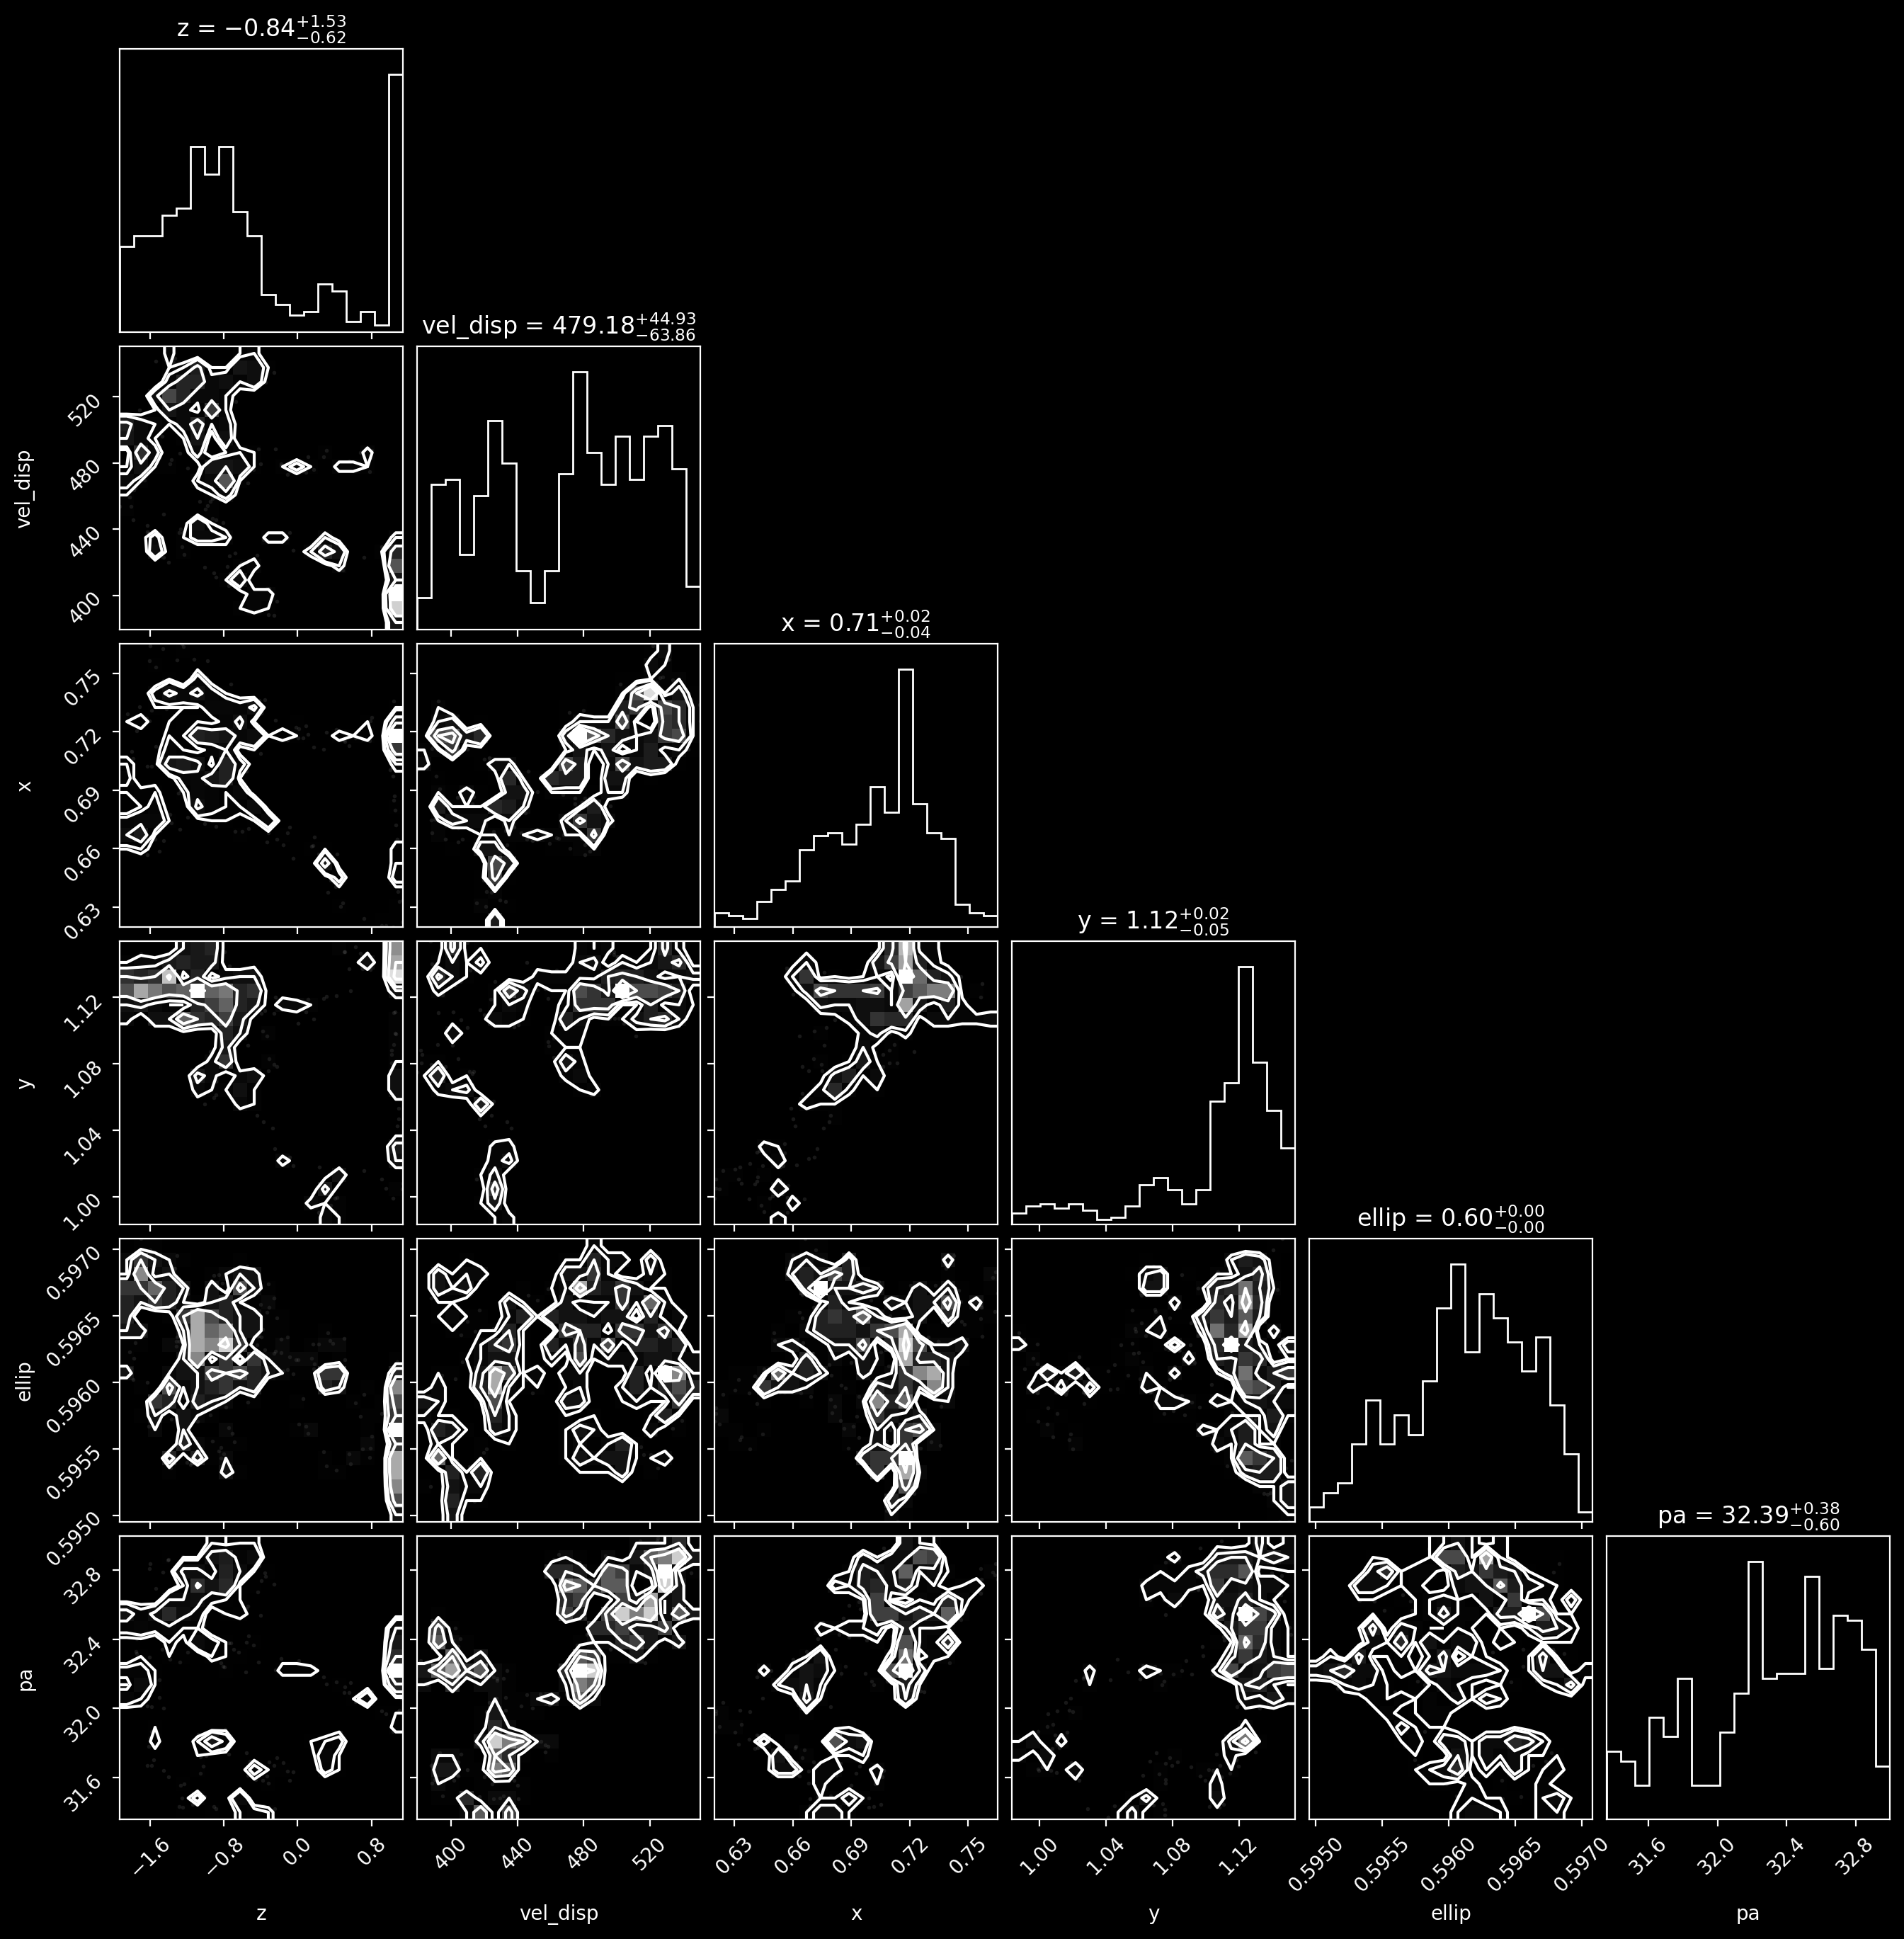

In [11]:
# Remove the first column when loading the samples, as it is the accepted/rejected column
labels = ['z', 'vel_disp', 'x', 'y', 'ellip', 'pa']
fig = corner.corner(masked_samples, labels=labels, show_titles=True)
plt.savefig(f'../{system_name}/mcmc/{model_ver}_corner.png')